In [3]:
import numpy as np
import pandas as pd

In [12]:
df=pd.read_csv("placement.csv")

In [13]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [14]:
df=df.iloc[:,1:]

In [5]:
df=df.iloc[:,1:]

In [6]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
import matplotlib.pyplot as plt

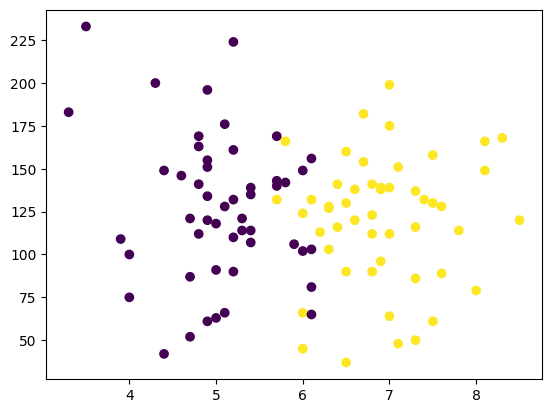

In [12]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])
plt.show()

In [15]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [16]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [19]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2)

In [22]:
x_train

,cgpa,iq
3,7.4,132.0
58,8.0,79.0
55,7.8,114.0
4,5.8,142.0
7,5.0,63.0
...,...,...
13,6.4,116.0
31,3.9,109.0
80,4.9,196.0
88,4.4,149.0


In [23]:
y_train

,placement
3,1
58,1
55,1
4,0
7,0
...,...
13,1
31,0
80,0
88,0


In [24]:
x_test

,cgpa,iq
77,7.3,50.0
45,6.0,66.0
82,6.5,37.0
48,6.6,138.0
52,7.0,175.0
67,5.0,118.0
81,5.4,107.0
98,6.3,103.0
38,6.5,160.0
53,8.3,168.0


In [25]:
y_test

,placement
77,1
45,1
82,1
48,1
52,1
67,0
81,0
98,1
38,1
53,1


In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler=StandardScaler()

In [28]:
x_train=scaler.fit_transform(x_train)

In [29]:
x_train

array([[ 1.26061692,  0.20134729],
       [ 1.791869  , -1.20278511],
       [ 1.61478497, -0.27552787],
       [-0.1560553 ,  0.46627793],
       [-0.86439141, -1.62667414],
       [ 0.90644886,  1.97638259],
       [ 1.34915893,  0.89016696],
       [ 0.99499088,  0.70471551],
       [ 0.99499088, -2.0240701 ],
       [-0.95293342, -0.11656948],
       [ 0.72936484, -0.328514  ],
       [ 0.90644886,  0.38679874],
       [-0.24459731,  0.49277099],
       [ 0.10957074,  0.20134729],
       [ 0.72936484,  0.43978487],
       [ 1.17207491, -1.01733366],
       [ 1.88041101,  0.65172938],
       [ 0.4637388 , -0.91136141],
       [-0.86439141, -0.88486834],
       [ 0.90644886, -0.328514  ],
       [ 0.10957074,  0.83718083],
       [-0.68730738, -0.38150012],
       [-1.04147544,  1.18159066],
       [ 1.17207491,  0.33381261],
       [-1.4841855 ,  2.00287565],
       [ 1.88041101,  1.10211147],
       [ 0.72936484, -0.91136141],
       [-1.74981154, -0.64643077],
       [-1.13001745,

In [31]:
x_test=scaler.transform(x_test)

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
clf=LogisticRegression()

In [34]:
#model training
clf.fit(x_train, y_train)

LogisticRegression()

In [37]:
y_pred=clf.predict(x_test)

In [36]:
y_test

,placement
77,1
45,1
82,1
48,1
52,1
67,0
81,0
98,1
38,1
53,1


In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(y_test, y_pred)

0.95

In [41]:
!pip install mlxtend


In [42]:
from mlxtend.plotting import plot_decision_regions


<Axes: >

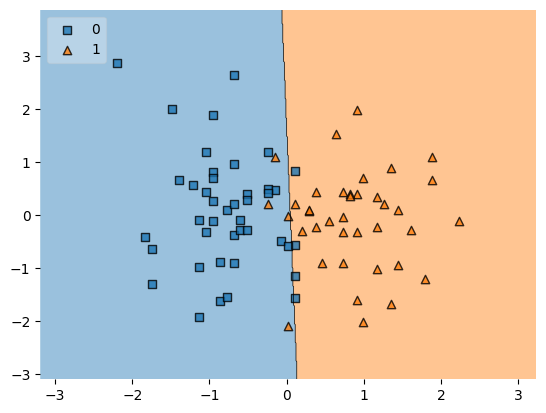

In [43]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [44]:
import pickle

In [45]:
pickle.dump(clf,open('model.pkl','wb'))